This notebook is second level exploratory. The goal here is to take charts I am next level considering to finalize and then adding cleaner features. 

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3


In [2]:
#Create dataframes
df_industry = pd.read_csv("../Data/ai_industry_summary.csv") 

In [3]:
df_company = pd.read_csv("../Data/ai_company_adoption.csv") 

In [4]:
df_country = pd.read_csv("../Data/country_ai_index.csv")

Text(0, 0.5, 'AI Adoption Rate %')

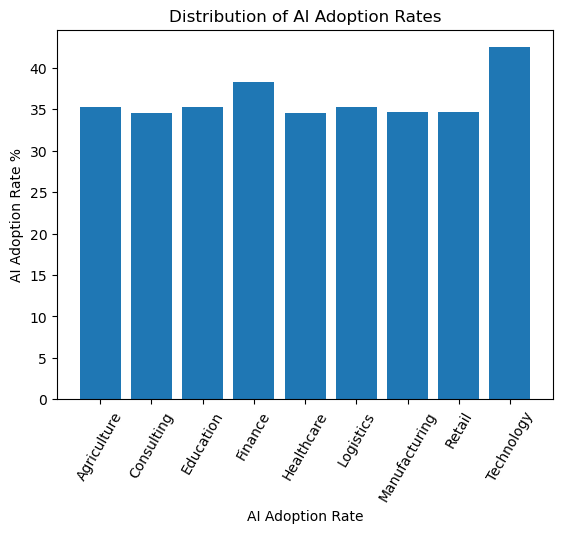

In [20]:
# Plot bar chart of AI Adoption Rates by Industry
plt.bar(df_industry['industry'], df_industry["avg_ai_adoption_rate"])
plt.title("Distribution of AI Adoption Rates")
plt.xticks(rotation=60)
plt.xlabel("AI Adoption Rate")
plt.ylabel("AI Adoption Rate %")

The bar chart above answers the question of how 

In [6]:
# Group by country and industry and then focus in on the ai adoption rate .mean()
country_industry = (
    df_company
    .groupby(["country", "industry"])["ai_adoption_rate"]
    .mean()
    .reset_index()
)

country_industry.head()

,country,industry,ai_adoption_rate
0,Argentina,Agriculture,32.432380
1,Argentina,Consulting,36.357964
2,Argentina,Education,30.827514
3,Argentina,Finance,38.770831
4,Argentina,Healthcare,30.699859


In [7]:
#calculation for choropleth
country_ai = (
    df_company
    .groupby("country")["ai_adoption_rate"]
    .mean()
    .reset_index()
)

country_ai.head()

,country,ai_adoption_rate
0,Argentina,34.327419
1,Australia,39.933564
2,Brazil,36.674198
3,Canada,39.120333
4,Chile,36.461705


In [8]:
# USE THIS BUT ADD MORE DETAIL
# Choropleth of world AI adoption
import plotly.express as px

fig = px.choropleth(
    country_ai,
    locations="country",
    locationmode="country names",
    color="ai_adoption_rate",
    hover_name="country",
    title="Global Average AI Adoption Rate"
)

fig.show()

C:\Users\patri\AppData\Local\Temp\ipykernel_18152\1761818179.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


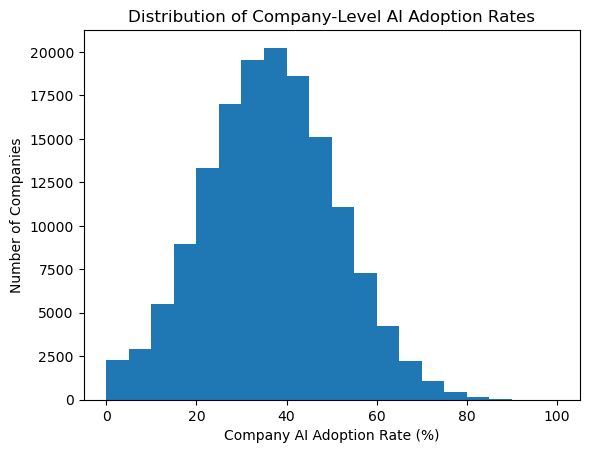

In [9]:
#USE THIS BUT ADD MORE DETAIL
plt.hist(
    df_company["ai_adoption_rate"],
    bins=20
)

plt.xlabel("Company AI Adoption Rate (%)")
plt.ylabel("Number of Companies")
plt.title("Distribution of Company-Level AI Adoption Rates")

plt.show()

The above histogram shows us the distribution of company-level AI adoption rates. The bins are telling us what percentage of a company's workflows have been touched by AI. The y axis is the number of companies. 

In [10]:
#Shows how many companies sit at the different levels of AI adoption
stage_counts= df_company["ai_adoption_stage"].value_counts()

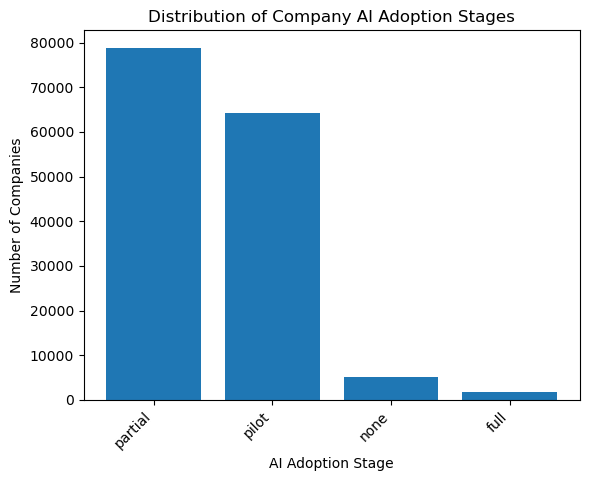

In [ ]:
plt.bar(
    stage_counts.index,
    stage_counts.values
)

plt.title("Distribution of Company AI Adoption Stages")
plt.xlabel("AI Adoption Stage")
plt.ylabel("Number of Global Companies")

plt.xticks(rotation=45, ha="right")

plt.show()

In [18]:
fig = px.choropleth(
    country_ai,
    locations="country",
    locationmode="country names",
    color="ai_adoption_rate",
    hover_name="country",
    color_continuous_scale="Plasma",
    range_color=(30,41),
    projection="natural earth",
    labels={
        "ai_adoption_rate": "Avg AI Adoption Rate (%)"
    },
    title="Global AI Adoption Intensity by Country"
)


fig.update_traces(
    marker_line_color="white",
    marker_line_width=0.4,
    hovertemplate=
        "<b>%{hovertext}</b><br>" +
        "AI Adoption Rate: %{z:.1f}%<extra></extra>"
)


fig.update_layout(

    
    paper_bgcolor="rgb(245,248,250)",
    plot_bgcolor="rgb(245,248,250)",

    title={
        "text": "Global AI Adoption Intensity by Country",
        "x": .5,
        "xanchor": "center",
        "font": {
            "size": 24,
            "color": "rgb(30,30,30)"
        }
    },

    geo=dict(
        showframe=False,
        showcoastlines=True,

        showocean=True,
        oceancolor="#78AAA8",

        showland=True,
        landcolor="rgb(215,220,220)",

        coastlinecolor="white",
        countrycolor="white",

        projection_type="natural earth"
    ),

    coloraxis_colorbar=dict(
    title="AI Adoption<br>Rate (%)",
    ticksuffix="%",
    thickness=15,
    len=.65,
    x=.85
),

    margin=dict(
        l=20,
        r=20,
        t=70,
        b=20
    )
)


fig.show()

C:\Users\patri\AppData\Local\Temp\ipykernel_18152\2384732345.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [19]:
fig.write_html(
    "../Images/global_ai_adoption_map.html"
)

The above globe is displaying average AI adoption rates per country. 